θ=1.00e-04 rad | kept=4080/5000 | err=25 | rate=2.04e-03
θ=1.00e-03 rad | kept=4040/5000 | err=19 | rate=1.57e-03
θ=1.00e-02 rad | kept=3766/5000 | err=25 | rate=2.21e-03
θ=1.00e-01 rad | kept=2843/5000 | err=13 | rate=1.52e-03
θ=1.00e+00 rad | kept=1145/5000 | err=30 | rate=8.73e-03


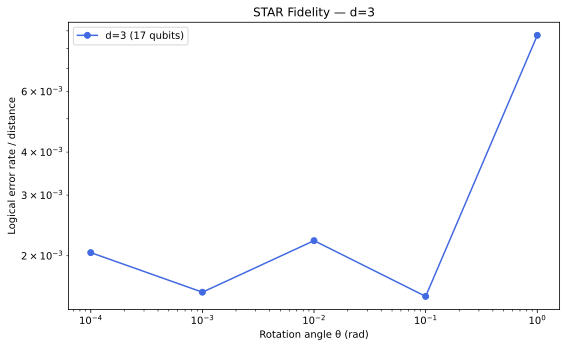

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from tsim import Circuit
import pymatching

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)

def load_stim_with_angle(path, d, logical_angle_in_pi):
    phys = physical_angle(logical_angle_in_pi, d)  # ya en π-units
    with open(path) as f: circ_str = f.read()
    matches = list(re.finditer(r'R_Z\([^)]+\)', circ_str))
    # Último primero para no invalidar índices
    last  = matches[-1]
    circ_str = circ_str[:last.start()]  + f'R_Z({-logical_angle_in_pi:.10f})' + circ_str[last.end():]
    first = matches[0]
    circ_str = circ_str[:first.start()] + f'R_Z({phys:.10f})'                 + circ_str[first.end():]
    return Circuit(circ_str)

# ── Solo d=3 ─────────────────────────────────────────────────────────────────
d              = 3
shots          = 5_000
num_postselect = 3 * (d**2 - 1)          # 24
angle_vals_rad = np.logspace(-4, 0, 5)  # θ en radianes
rates          = []

for theta_rad in angle_vals_rad:
    logical_angle_in_pi = theta_rad / np.pi  # convertir rad → π-units

    circ    = load_stim_with_angle(f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=logical_angle_in_pi)
    dem     = circ.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(dem)
    sampler = circ.compile_detector_sampler()

    detections, observations = sampler.sample(shots, separate_observables=True)
    predictions  = matcher.decode_batch(detections)

    postselected = [i for i in range(len(detections)) if not any(detections[i][:num_postselect])]
    num_errors   = sum(1 for idx in postselected if not np.array_equal(observations[idx], predictions[idx]))
    n_kept       = len(postselected)
    rate         = (num_errors / n_kept / d) if n_kept > 0 else np.nan
    rates.append(rate if rate and rate > 0 else np.nan)
    print(f"θ={theta_rad:.2e} rad | kept={n_kept}/{shots} | err={num_errors} | rate={rate:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
vals = [(t, r) for t, r in zip(angle_vals_rad, rates) if not np.isnan(r)]
if vals: ax.plot(*zip(*vals), "o-", color="royalblue", label="d=3 (17 qubits)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)")
ax.set_ylabel("Logical error rate / distance")
ax.legend(); ax.set_title("STAR Fidelity — d=3")
plt.tight_layout(); plt.show()


d=3...


E0510 11:10:28.901973 1414027 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.41 = s32[4100041,1,4]{2,1,0} gather(%constant.719, %broadcast.722), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,4}, metadata={op_name="jit(_sample_component_jit)/jit(evaluate)/gather" stack_frame_id=274}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0510 11:10:29.394895 1414008 slow_operation_alarm.cc:140] The operation took 1.497965s
Constant folding an instruction is taking > 1s:

  %gather.41 = s32[4100041,1,4]{2,1,0} gather(%constant.719, %broadcast.722), offset_

  θ=1.00e-04 | kept=81624/100000 | err=501 | rate=2.05e-03
  θ=1.00e-03 | kept=80069/100000 | err=478 | rate=1.99e-03
  θ=1.00e-02 | kept=75082/100000 | err=504 | rate=2.24e-03
  θ=1.00e-01 | kept=56116/100000 | err=371 | rate=2.20e-03
  θ=1.00e+00 | kept=23070/100000 | err=499 | rate=7.21e-03

d=5...
  θ=1.00e-04 | kept=51633/100000 | err=12 | rate=4.65e-05
  θ=1.00e-03 | kept=45355/100000 | err=4 | rate=1.76e-05
  θ=1.00e-02 | kept=32460/100000 | err=7 | rate=4.31e-05
  θ=1.00e-01 | kept=15328/100000 | err=16 | rate=2.09e-04
  θ=1.00e+00 | kept=4059/100000 | err=188 | rate=9.26e-03

d=7...
  θ=1.00e-04 → AssertionError, skipping
  θ=1.00e-03 | kept=15828/100000 | err=1 | rate=9.03e-06
  θ=1.00e-02 | kept=8533/100000 | err=1 | rate=1.67e-05
  θ=1.00e-01 | kept=2865/100000 | err=1 | rate=4.99e-05
  θ=1.00e+00 | kept=645/100000 | err=58 | rate=1.28e-02


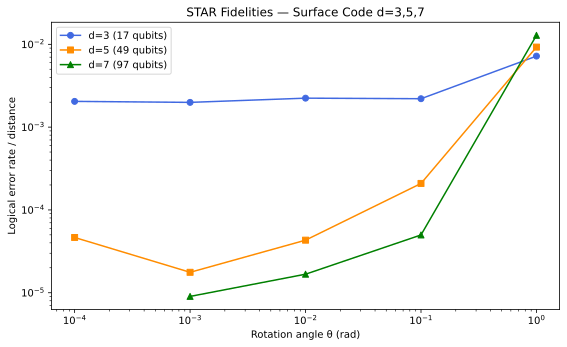

In [ ]:
distances      = [3, 5, 7]
shots          = 100_000
angle_vals_rad = np.logspace(-4, 0, 5)
results        = {d: [] for d in distances}

for d in distances:
    print(f"\nd={d}...")
    num_postselect = 3 * (d**2 - 1)
    for theta_rad in angle_vals_rad:
        logical_angle_in_pi = theta_rad / np.pi
        circ    = load_stim_with_angle(f"assets/star_circuits/star_d={d}.stim", d=d, logical_angle_in_pi=logical_angle_in_pi)
        dem     = circ.detector_error_model()
        matcher = pymatching.Matching.from_detector_error_model(dem)
        sampler = circ.compile_detector_sampler()

        try:
            detections, observations = sampler.sample(shots, separate_observables=True)
        except AssertionError:
            print(f"  θ={theta_rad:.2e} → AssertionError, skipping")
            results[d].append(np.nan)
            continue

        predictions  = matcher.decode_batch(detections)
        postselected = [i for i in range(len(detections)) if not any(detections[i][:num_postselect])]
        num_errors   = sum(1 for idx in postselected if not np.array_equal(observations[idx], predictions[idx]))
        n_kept       = len(postselected)
        rate         = (num_errors / n_kept / d) if n_kept > 0 else np.nan
        results[d].append(rate if rate and rate > 0 else np.nan)
        print(f"  θ={theta_rad:.2e} | kept={n_kept}/{shots} | err={num_errors} | rate={rate:.2e}")
fig, ax = plt.subplots(figsize=(8, 5))
for d, col, mk, lbl in [(3,"royalblue","o","d=3 (17 qubits)"),
                         (5,"darkorange","s","d=5 (49 qubits)"),
                         (7,"green","^","d=7 (97 qubits)")]:
    vals = [(t, r) for t, r in zip(angle_vals_rad, results[d]) if r and not np.isnan(r)]
    if vals: ax.plot(*zip(*vals), color=col, marker=mk, label=lbl, linewidth=1.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Rotation angle θ (rad)")
ax.set_ylabel("Logical error rate / distance")
ax.legend(); ax.set_title("STAR Fidelities — Surface Code d=3,5,7")
plt.tight_layout(); plt.show()